In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [8]:
# Pemrosesan Data
df = pd.read_csv('spotify2023.csv', sep=",", encoding="ISO-8859-1", header=0)
selected_features = df[['track_name', 'danceability_%', 'valence_%', 'energy_%']]
selected_features = selected_features.dropna()  # Menghapus baris yang nilainya null
selected_features[['danceability_%', 'valence_%', 'energy_%']] = selected_features
[['danceability_%', 'valence_%', 'energy_%']].apply(pd.to_numeric, errors='coerce')
selected_features.fillna(selected_features.mean(), inplace=True)

C:\Users\Asus\AppData\Local\Temp\ipykernel_3440\1791763931.py:6: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  selected_features.fillna(selected_features.mean(), inplace=True)


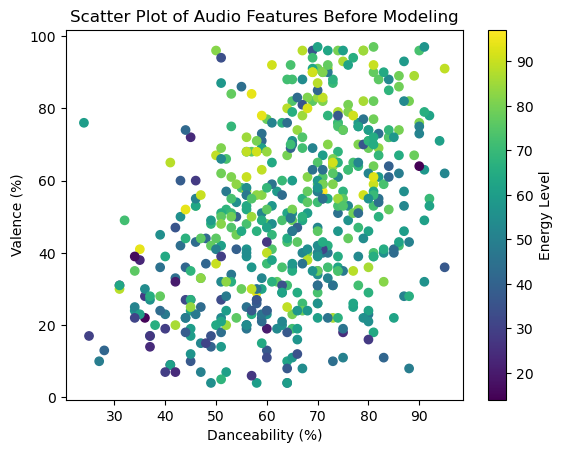

In [9]:
# Visualisasi Data sebelum pemodelan
plt.scatter(selected_features['danceability_%'], selected_features['valence_%'],c=selected_features['energy_%'], cmap='viridis')
plt.colorbar(label='Energy Level')
plt.xlabel('Danceability (%)')
plt.ylabel('Valence (%)')
plt.title('Scatter Plot of Audio Features Before Modeling')
plt.show()

In [10]:
# Pemodelan K-Means
X = selected_features[['danceability_%', 'valence_%', 'energy_%']]
kmeans = KMeans(n_clusters=3)
kmeans.fit(X)
selected_features['cluster'] = kmeans.labels_

C:\Users\Asus\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\Asus\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


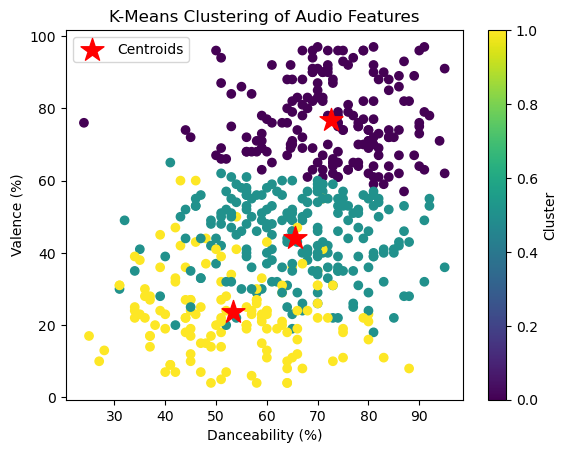

In [11]:
# Visualisasi Hasil dengan Pemodelan
plt.scatter(selected_features['danceability_%'], selected_features['valence_%'], c=selected_features['cluster'], cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], marker='*', s=300, c='red', label='Centroids')
plt.colorbar(label='Cluster')
plt.xlabel('Danceability (%)')
plt.ylabel('Valence (%)')
plt.title('K-Means Clustering of Audio Features')
plt.legend()
plt.show()

In [12]:
# Informasi Cluster
cluster_info = selected_features.groupby('cluster').mean()
cluster_count = selected_features['cluster'].value_counts()

C:\Users\Asus\AppData\Local\Temp\ipykernel_3440\3389795259.py:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  cluster_info = selected_features.groupby('cluster').mean()


In [15]:
# Deskripsi cluster 0-2
for cluster_num in range(len(cluster_info)):
    print(f"\nCluster {cluster_num} Summary:")
    print("Average Danceability:", cluster_info.loc[cluster_num, 'danceability_%'])
    print("Average Valence:", cluster_info.loc[cluster_num, 'valence_%'])
    print("Average Energy:", cluster_info.loc[cluster_num, 'energy_%'])
    print("Number of Songs:", cluster_count[cluster_num])
    
    # Deskripsi tambahan
    print("This cluster represents songs that:")
    if cluster_info.loc[cluster_num, 'danceability_%'] > 50:
        print("- Have higher than average danceability.")
    else:
        print("- Have lower than average danceability.")

    if cluster_info.loc[cluster_num, 'valence_%'] > 50:
        print("- Have higher than average valence (positivity).")
    else:
        print("- Have lower than average valence (positivity).")

    if cluster_info.loc[cluster_num, 'energy_%'] > 50:
        print("- Have higher than average energy.")
    else:
        print("- Have lower than average energy.")

    print(f"Number of Songs in Cluster {cluster_num}: {cluster_count[cluster_num]}")


Cluster 0 Summary:
Average Danceability: 72.62524038461538
Average Valence: 76.72727272727273
Average Energy: 68.67045454545455
Number of Songs: 176
This cluster represents songs that:
- Have higher than average danceability.
- Have higher than average valence (positivity).
- Have higher than average energy.
Number of Songs in Cluster 0: 176

Cluster 1 Summary:
Average Danceability: 65.48038643820634
Average Valence: 44.119851748479874
Average Energy: 67.56872037914692
Number of Songs: 211
This cluster represents songs that:
- Have higher than average danceability.
- Have lower than average valence (positivity).
- Have higher than average energy.
Number of Songs in Cluster 1: 211

Cluster 2 Summary:
Average Danceability: 53.32608695652174
Average Valence: 23.55072463768116
Average Energy: 44.89855072463768
Number of Songs: 138
This cluster represents songs that:
- Have higher than average danceability.
- Have lower than average valence (positivity).
- Have lower than average energy.
N

In [16]:
# Deskripsi cluster 0-2
for cluster_num in range(len(cluster_info)):
    print(f"\nCluster {cluster_num} Summary:")
    print("Average Danceability:", cluster_info.loc[cluster_num, 'danceability_%'])
    print("Average Valence:", cluster_info.loc[cluster_num, 'valence_%'])
    print("Average Energy:", cluster_info.loc[cluster_num, 'energy_%'])
    print("Number of Songs:", cluster_count[cluster_num])

    # Deskripsi tambahan
    print("This cluster represents songs that:")
    if cluster_info.loc[cluster_num, 'danceability_%'] > 50:
        print("- Have higher than average danceability.")
    else:
        print("- Have lower than average danceability.")

    if cluster_info.loc[cluster_num, 'valence_%'] > 50:
        print("- Have higher than average valence (positivity).")
    else:
        print("- Have lower than average valence (positivity).")

    if cluster_info.loc[cluster_num, 'energy_%'] > 50:
        print("- Have higher than average energy.")
    else:
        print("- Have lower than average energy.")

    print(f"Number of Songs in Cluster {cluster_num}: {cluster_count[cluster_num]}")


Cluster 0 Summary:
Average Danceability: 72.62524038461538
Average Valence: 76.72727272727273
Average Energy: 68.67045454545455
Number of Songs: 176
This cluster represents songs that:
- Have higher than average danceability.
- Have higher than average valence (positivity).
- Have higher than average energy.
Number of Songs in Cluster 0: 176

Cluster 1 Summary:
Average Danceability: 65.48038643820634
Average Valence: 44.119851748479874
Average Energy: 67.56872037914692
Number of Songs: 211
This cluster represents songs that:
- Have higher than average danceability.
- Have lower than average valence (positivity).
- Have higher than average energy.
Number of Songs in Cluster 1: 211

Cluster 2 Summary:
Average Danceability: 53.32608695652174
Average Valence: 23.55072463768116
Average Energy: 44.89855072463768
Number of Songs: 138
This cluster represents songs that:
- Have higher than average danceability.
- Have lower than average valence (positivity).
- Have lower than average energy.
N

In [17]:
# Visualisasi tambahan
plt.figure(figsize=(10, 5))

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

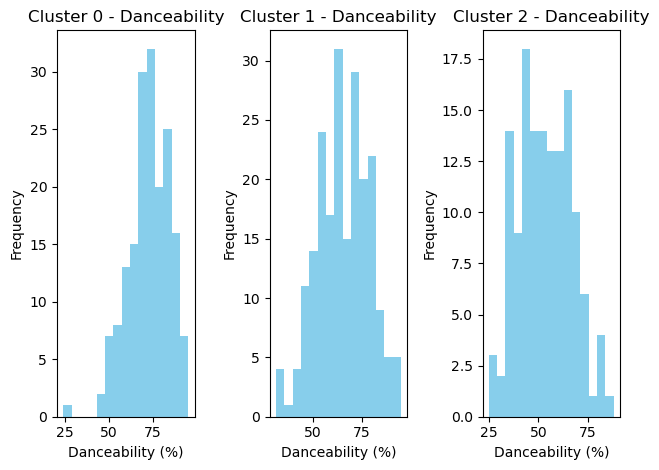

In [18]:
# Histogram Danceability cluster 0-2
for i in range(3):
    plt.subplot(1, 3, i + 1)
    plt.hist(selected_features[selected_features['cluster'] == i]['danceability_%'], bins=15, color='skyblue')
    plt.title(f'Cluster {i} - Danceability')
    plt.xlabel('Danceability (%)')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

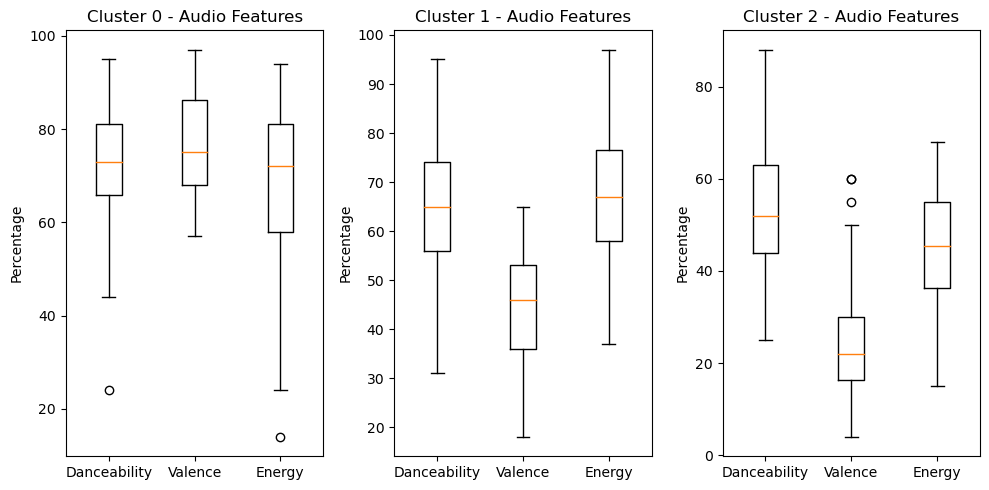

In [19]:
# Boxplot untuk fitur audio cluster 0-2
plt.figure(figsize=(10, 5))
for i in range(3):
    plt.subplot(1, 3, i + 1)
    plt.boxplot([selected_features[selected_features['cluster'] == i]['danceability_%'],
                 selected_features[selected_features['cluster'] == i]['valence_%'],
                 selected_features[selected_features['cluster'] == i]['energy_%']])
    plt.title(f'Cluster {i} - Audio Features')
    plt.xticks([1, 2, 3], ['Danceability', 'Valence', 'Energy'])
    plt.ylabel('Percentage')

plt.tight_layout()
plt.show()

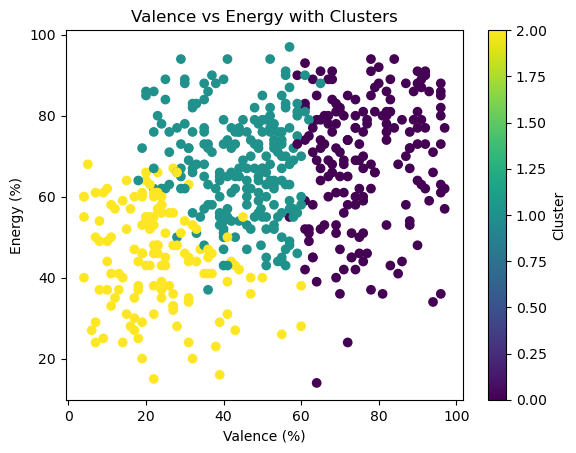

In [20]:
# Scatter plot untuk Valence dan Energy
plt.scatter(selected_features['valence_%'], selected_features['energy_%'], c=selected_features['cluster'], cmap='viridis')
plt.colorbar(label='Cluster')
plt.xlabel('Valence (%)')
plt.ylabel('Energy (%)')
plt.title('Valence vs Energy with Clusters')
plt.show()

In [21]:
# Interpretasi Cluster
print("\nInterpretation of Clusters:")
print("Cluster 0: Songs with lower danceability and energy but higher valence, likely more relaxed and emotionally positive.")
print("Cluster 1: Songs with higher danceability and valence, with moderate energy, possibly more cheerful and energetic.")
print("Cluster 2: Songs with higher danceability but lower valence and energy, tending to be calmer and less cheerful.")


Interpretation of Clusters:
Cluster 0: Songs with lower danceability and energy but higher valence, likely more relaxed and emotionally positive.
Cluster 1: Songs with higher danceability and valence, with moderate energy, possibly more cheerful and energetic.
Cluster 2: Songs with higher danceability but lower valence and energy, tending to be calmer and less cheerful.


In [22]:
# Deskripsi fitur audio
print("\nAudio Features Description:")
print("- Danceability (%): Indicates the suitability of a track for dancing.")
print("- Valence (%): Describes the musical positivity.")
print("- Energy (%): Indicates the intensity and activity in music.")


Audio Features Description:
- Danceability (%): Indicates the suitability of a track for dancing.
- Valence (%): Describes the musical positivity.
- Energy (%): Indicates the intensity and activity in music.


In [23]:
# Kesimpulan
print("\nConclusion:")
print("Cluster 1 contains songs that are more cheerful and energetic, while Cluster 0 tends to be more relaxed.")


Conclusion:
Cluster 1 contains songs that are more cheerful and energetic, while Cluster 0 tends to be more relaxed.
